In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReActAgent"

In [7]:
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_core.messages import AIMessage, HumanMessage
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

In [3]:
arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500))
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500))

In [4]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a & b.
    Args:
        a: first number
        b: second number
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    Adds a & b.
    Args:
        a: first number
        b: second number
    """
    return a + b

def divide(a: int, b: int) -> float:
    """
    Divides a & b.
    Args:
        a: first number
        b: second number
    """
    return a / b

In [5]:
tools = [arxiv, wiki, add, divide, multiply]

In [8]:
llm = ChatGroq(model="qwen/qwen3-32b", groq_api_key=GROQ_API_KEY)

In [9]:
llm_with_tools = llm.bind_tools(tools=tools)

### Implementation of ReAct

In [10]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [11]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [12]:
builder = StateGraph(State)
builder.add_node("llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)
builder.add_edge("tools", "llm")

In [13]:
graph = builder.compile()

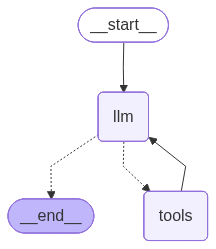

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages = graph.invoke({"messages": HumanMessage(content="What is attention is all you need?")})
for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is attention is all you need?
================================== Ai Message ==================================
Tool Calls:
  arxiv (fr6f71txy)
 Call ID: fr6f71txy
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi
================================== Ai Message ==================================

The phrase "Attention Is All

In [16]:
messages = graph.invoke({"messages": HumanMessage(content="Add 5 and 10. Then multiply it by 20. Also provide me info on Attention is all you need")})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 5 and 10. Then multiply it by 20. Also provide me info on Attention is all you need
================================== Ai Message ==================================
Tool Calls:
  add (1bp42f89h)
 Call ID: 1bp42f89h
  Args:
    a: 5
    b: 10
  multiply (85z7x3k5t)
 Call ID: 85z7x3k5t
  Args:
    a: 15
    b: 20
  arxiv (r4awhsbje)
 Call ID: r4awhsbje
  Args:
    query: Attention is all you need
================================= Tool Message =================================
Name: add

15
================================= Tool Message =================================
Name: multiply

300
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classificat